# WGTDA: Patient Phenotype Prediction Tutorial

This tutorial demonstrates the **WGTDA prediction framework** for classifying patient phenotypes using gene expression data.

Each patient's gene expression profile is used to compute individual weights, which are used to construct a **simplicial complex** and compute **persistent homology**. The resulting topological features (persistence landscapes) are then used as input to a machine learning classifier and compared against a baseline trained on raw gene expression.

![Patient Prediction Framework](../../docs/imgs/ML_framework.png)

## Task Description

In this case we are predicting **radiotherapy treatment response** — classifying patients as either **Resistant** (no response to treatment) or **Sensitive** (positive response to treatment) based on their tumour gene expression profiles.
The dataset used is the **Clinical Proteomic Tumor Analysis Consortium (CPTAC) Radiotherapy Response** cohort. 

Predicting radiotherapy response fromtranscriptomic data is clinically important for identifying patients likely to benefit
from radiation while minimizing unnecessary toxicity. This task remains challenging due to the complex interplay between intrinsic tumor characteristics, such as mutational background, DNA repair capacity, and extrinsic influences from the tumor
microenvironment. 


## Tutorial Steps
1. Import required modules.
2. Load gene expression data (CPTAC Radiotherapy Response dataset).
3. Filter to significant genes and prepare the expression matrix.
4. Split data into train/test sets and encode labels.
5. Train a baseline Random Forest on raw gene expression.
6. Compute Co-expression Matrix and Generate Persistence Landscapes.
7. Train a Random Forest on WGTDA landscape features.
8. Compare classification performance between both approaches.


## Step 1: Import Modules

Import the required libraries:
- **`src.tda.pipeline_prediction`** — builds the simplicial complex, computes persistent homology, and extracts persistence landscapes per patient.
- **`src.correlation.dtem`** — computes the DTEM co-expression matrix used to weight the simplicial complex construction.
- **`sklearn`** — provides the Random Forest classifier, label encoding, and evaluation metrics.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
import pandas as pd
import numpy as np
import src.tda.pipeline_prediction as tda_pred
from sklearn.calibration import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import src.correlation.dtem as dtem

## Step 2: Load Gene Expression Data

Load the gene expression dataset. This tutorial uses the **Clinical Proteomic Tumor Analysis Consortium (CPTAC) Radiotherapy Response** dataset, where each row is a patient sample and columns are gene FPKM values. A `phenotype` column encodes the treatment response label (**Resistant** or **Sensitive**), which is used as the classification target.


In [2]:
project_root = os.path.abspath('../..')
treatment_response_path = os.path.join(project_root, 'data/paper/clinical_outcome_prediction/treatment_response_radiotherapy/fpkm_matrix.csv')
DEG_path = os.path.join(project_root, 'data/paper/clinical_outcome_prediction/treatment_response_radiotherapy/DEG_genes.csv')

expression_matrix = pd.read_csv(treatment_response_path)
print(expression_matrix.head(2))

                                          Unnamed: 0   phenotype   TSPAN6  \
0  4e83f0d1-c225-4d25-9e8e-d443999493d4.rna_seq.a...  Resistance   8.5401   
1  18f0d923-c97c-4733-9f57-e48669262066.rna_seq.a...  Resistance  11.9435   

     TNMD     DPM1   SCYL3  C1orf112      FGR      CFH    FUCA2  ...  \
0  0.1212  17.1960  3.7217    3.2169   5.6345   7.6795   4.8505  ...   
1  0.1191  25.1733  4.5421    3.3815  10.3356  70.3644  16.6020  ...   

   ACTL10.3  AC119733.1  AC020765.6  AC010980.1  AC004233.4  AL451106.1  \
0       0.0         0.0         0.0      0.4925         0.0         0.0   
1       0.0         0.0         0.0      0.1185         0.0         0.0   

   AC008763.4  AC006486.3  AL391628.1  AP006621.6  
0         0.0         0.0      0.0093      0.4615  
1         0.0         0.0      0.0487      0.4709  

[2 rows x 20012 columns]


### Data Overview

Before proceeding, let's inspect the dataset dimensions and class balance to confirm the data loaded correctly.


In [3]:
print(f"Total samples : {expression_matrix.shape[0]}")
print(f"Total genes   : {expression_matrix.shape[1] - 1}")  # exclude phenotype column
print(f"\nClass distribution:\n{expression_matrix['phenotype'].value_counts()}")


Total samples : 453
Total genes   : 20011

Class distribution:
phenotype
Sensitive     347
Resistance    106
Name: count, dtype: int64


## Step 3: Gene Preselection

Due to the computational overhead of computing topological features in high-dimensional spaces, we restrict our analysis to a preselected set of **differentially expressed genes (DEGs)** between treatment-sensitive and treatment-resistant patients. This reduces the feature space while retaining the most biologically informative signal.


In [4]:
preselection_genes = pd.read_csv(DEG_path, index_col=0).index.tolist()
phenotype = expression_matrix["phenotype"]
gene_list = preselection_genes
sig_exp_matrix = expression_matrix[gene_list].copy()
sig_exp_matrix["phenotype"] = phenotype.values

print(f"Samples : {sig_exp_matrix.shape[0]}")
print(f"DEGs    : {len(gene_list)}")
print(f"\nClass distribution:\n{sig_exp_matrix['phenotype'].value_counts()}")


Samples : 453
DEGs    : 103

Class distribution:
phenotype
Sensitive     347
Resistance    106
Name: count, dtype: int64


## Step 4: Split and Preprocess the Dataset

The filtered expression matrix is split into **training (70%)** and **test (30%)** sets using stratified sampling to preserve the class distribution of the `phenotype` label across both splits.

The feature matrix (`X`) and label vector (`y`) are then extracted separately:
- **`X_train_expr` / `X_test_expr`** — gene expression values (one row per patient, one column per DEG).
- **`y_train` / `y_test`** — treatment response labels, integer-encoded using `LabelEncoder` (e.g., `Resistant → 0`, `Sensitive → 1`).


In [5]:
train_df, test_df = train_test_split(
        sig_exp_matrix,
        test_size=0.3,
        random_state=2,
        stratify=sig_exp_matrix["phenotype"]
    )

print(train_df)

X_train_expr = train_df.drop(columns=["phenotype"]).values
X_test_expr = test_df.drop(columns=["phenotype"]).values
y_train = train_df["phenotype"].values
y_test = test_df["phenotype"].values

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

        AOC1     PDK4   CLDN11   IL20RA    BCAS1  COL17A1     HES2     LRP2  \
441  67.9932   9.1030   0.1527  24.0753   9.2870  30.0945  11.7314   0.7521   
232   0.0956  18.4340   0.4428  14.5499   0.9601   0.9470   4.9057   2.5999   
439   1.1360  13.7019   0.0677   8.4434   0.4396   0.8456   0.8874   0.5649   
79    0.3324  12.3592   0.7119   3.2516   0.5466   0.3868   2.0342   4.7014   
371   0.4672   3.1138   0.1153   3.2652   1.3146   0.5845   1.7230   0.7531   
..       ...      ...      ...      ...      ...      ...      ...      ...   
217   1.3066   5.7154   5.5095  12.8768   7.1760   2.8312   3.2593   6.5447   
222   0.2653   6.6303   6.6885   0.7018  16.3678   0.1836   0.0464   3.1604   
273   3.9851  11.9437   0.4358  10.6325   0.3902   2.3873   1.7721   0.5297   
141   5.7160   7.7087   0.1631   3.4403   0.9550   2.3187   1.0363  11.9157   
278   0.1066  12.2508  12.1589   9.1122   0.2343   1.4948   0.1400   0.2318   

          PGR      OVGP1  ...  SERPINA5    S100A2  

## Step 5: Train a Machine Learning Model Baseline on Raw Gene Expression (Baseline Random Forest)

As a baseline, we train a **Random Forest classifier** directly on the raw DEG expression values. This establishes the classification performance achievable without any topological feature extraction, and serves as the comparison point for the WGTDA approach in Step 7.

The `train_rf` helper function:
1. Fits a `RandomForestClassifier` on the training set.
2. Predicts labels for the test set.
3. Reports **accuracy** and **weighted F1-score**.


In [6]:
def train_rf(X_train, y_train, X_test, y_test, label: str):
    """Train a Random Forest and print metrics."""
    clf = RandomForestClassifier(random_state=1)

    print(f"\n🧬 Training Random Forest on {label}...")
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average="weighted")

    print(f"➡ Results ({label}):")
    print(f"   Accuracy   : {acc:.3f}")
    print(f"   F1 weighted: {f1w:.3f}")

    return clf, acc, f1w

# Baseline: Random Forest on raw gene expression
_expr_clf, expr_acc, expr_f1 = train_rf(
    X_train_expr, y_train, X_test_expr, y_test,
    label="Raw Gene Expression (DEG)"
)




🧬 Training Random Forest on Raw Gene Expression (DEG)...
➡ Results (Raw Gene Expression (DEG)):
   Accuracy   : 0.772
   F1 weighted: 0.739


## Step 6: Compute DTEM Co-expression Matrix and Generate Persistence Landscapes

**6a — DTEM Co-expression Matrix**

The **Distance to Empirical Measure (DTEM)** is a robust, outlier-resistant co-expression measure. For each pair of genes, it computes the square norm between a data point $x$ and its $k$ nearest neighbours in the dataset $X_n$:

$$\rho = \frac{1}{k}\sum_{j=1}^{k}\|x - X_n\|_{(j)}^2$$

The $1/k$ normalisation factor reduces the influence of outliers, making the resulting gene × gene matrix a stable population-level reference for weighting each patient's simplicial complex.

> **Note:** The DTEM matrix is computed **only on the training set** to prevent data leakage; the same matrix is applied to the test set.




In [7]:
coexpression_matrix = dtem.compute_dtem_matrix(X_train_expr)

**6b — Persistence Landscapes (Train & Test)**

For each patient, `run_prediction_pipeline`:
1. Weights the patient's gene expression vector against the DTEM population matrix.
2. Builds a **Rips complex** and computes **persistent homology** in dimensions 0, 1, and 2.
3. Vectorises the birth–death intervals as **persistence landscapes**, which are concatenated into a fixed-length feature vector per patient.

**Key hyperparameters:**

| Parameter | Value | Description |
|---|---|---|
| `num_layers` | 2 | Number of landscape layers per homological dimension. More layers capture finer topological detail but increase feature size. |
| `resolution` | 100 | Number of sample points for the landscape function. Higher values give finer resolution at the cost of compute time. |
| `max_dim` | 2 | Maximum homological dimension. Dim 0 = connected components, Dim 1 = loops, Dim 2 = voids. |

In [8]:
num_layers = 2
resolution = 100
max_dim = 2

print("\n🏗 Computing TDA landscapes (train)...")
landscapes_train = tda_pred.run_prediction_pipeline(
        X_train_expr,
        coexpression_matrix,
        num_layers=num_layers,
        resolution=resolution,
        max_dim=max_dim,
    )
    
print("\n🏗 Computing TDA landscapes (test)...")
landscapes_test = tda_pred.run_prediction_pipeline(
        X_test_expr,
        coexpression_matrix,
        num_layers=num_layers,
        resolution=resolution,
        max_dim=max_dim,
    )
landscapes_train = np.nan_to_num(landscapes_train)
landscapes_test = np.nan_to_num(landscapes_test)


🏗 Computing TDA landscapes (train)...


Computing diagrams: 100%|██████████| 317/317 [00:03<00:00, 100.23it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value

🏗 Computing TDA landscapes (test)...


Computing diagrams: 100%|██████████| 136/136 [00:01<00:00, 102.08it/s]

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value



/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


## Step 7: Train Random Forest on TDA Landscape Features and Compare Results

Using the persistence landscape feature matrices computed in Step 6, we train a second **Random Forest classifier** — this time using topological features rather than raw gene expression values.

The final summary compares both classifiers side-by-side:
- **Raw Expression RF** — trained directly on DEG FPKM values (baseline).
- **WGTDA Landscapes RF** — trained on persistence landscape features derived from patient-level simplicial complexes.

A higher accuracy or F1-score for the WGTDA model demonstrates that the topological representation captures biologically meaningful structure beyond what is encoded in raw expression alone.


In [9]:
# Train Random Forest on TDA landscape features
_tda_clf, tda_acc, tda_f1 = train_rf(
    landscapes_train, y_train, landscapes_test, y_test,
    label="WGTDA Landscapes (DEG)"
)

print("\n✅ Summary:")
print(f"Raw Expression RF   -> Acc: {expr_acc:.3f}, F1w: {expr_f1:.3f}")
print(f"WGTDA Landscapes RF -> Acc: {tda_acc:.3f}, F1w: {tda_f1:.3f}")



🧬 Training Random Forest on WGTDA Landscapes (DEG)...
➡ Results (WGTDA Landscapes (DEG)):
   Accuracy   : 0.765
   F1 weighted: 0.714

✅ Summary:
Raw Expression RF   -> Acc: 0.772, F1w: 0.739
WGTDA Landscapes RF -> Acc: 0.765, F1w: 0.714


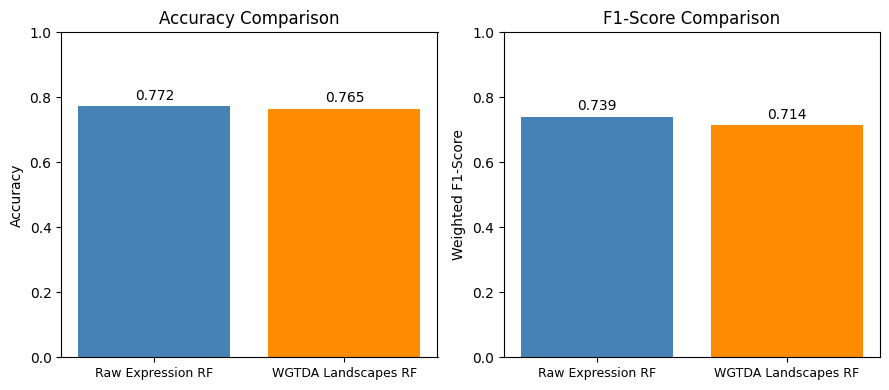

In [10]:
import matplotlib.pyplot as plt

models = ["Raw Expression RF", "WGTDA Landscapes RF"]
accuracies = [expr_acc, tda_acc]
f1_scores = [expr_f1, tda_f1]

x = range(len(models))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(x, accuracies, color=["steelblue", "darkorange"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy Comparison")
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

axes[1].bar(x, f1_scores, color=["steelblue", "darkorange"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Weighted F1-Score")
axes[1].set_title("F1-Score Comparison")
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


## Conclusion

This tutorial demonstrated the **WGTDA prediction framework** applied to radiotherapy treatment-response classification using the CPTAC dataset.

By replacing raw gene expression features with **patient-level persistence landscapes**, WGTDA captures the topological shape of each patient's co-expression network — a signal that complements standard differential expression analysis.

**Key takeaways:**
- The DTEM co-expression matrix provides a population-level, outlier-robust weighting for simplicial complex construction.
- Persistence landscapes from dimensions 0, 1, and 2 encode connected components, loops, and voids in the gene co-expression topology.
- Topological features can improve classification performance over raw expression alone.

**Next steps:**
- Explore the `tutorial_discovery.ipynb` notebook to analyse co-occurrence networks, hub genes, and KEGG enrichment for each patient.
- Experiment with `num_layers`, `resolution`, and `max_dim` to tune the landscape feature representation for your dataset.
- Try different classifiers (e.g., SVM, gradient boosting) on the landscape features as a drop-in replacement for `train_rf`.
